### 본 코드가 설명하는 ViT 파이프라인은 다음 순서로 진행됨

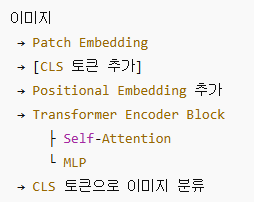


<span style="font-size:13px;"> 
<span style="color: lightblue"> Self-Attention 핵심 정리 </span>


**1. 내적(Dot Product)이란?**
- 두 벡터가 얼마나 같은 방향을 보는지를 하나의 숫자로 나타낸 것
- 의미
    - 방향이 비슷할수록 값이 큼
    - 직각이면 0
    - 반대 방향이면 음수
    - 벡터의 크기도 함께 반영됨

=> **내적 = 방향 유사도 + 크기 영향**  

<br>

**2. Attention의 전체 흐름**

- 내적(Dot Product) → 관련성
- 스케일링(√d)      → 안정성
- Softmax          → 선택
- 가중합(Σ w·V)    → 정보 조합  

<br>

**3. 왜 Q · K 가 “관련성”이 되는가**  

Attention이 묻는 핵심 질문:
> “이 토큰은 다른 어떤 토큰을 참고해야 하나?”

이를 수식으로 표현하면:
Query · Key

* **Query(Q)** : 내가 찾고 있는 방향
* **Key(K)**   : 내가 가지고 있는 방향

* **Query(Q)** : 내가 찾고 있는 방향
* **Key(K)**   : 내가 가지고 있는 방향

방향이 맞음 -> 내적 큼 -> 주목
방향 다름 -> 내적 작음 -> 무시

=> 그래서 **Q · K = 관련성 점수**  

<br>

**4. Query / Key / Value의 역할**
- Query (Q)
> "나는 무엇을 찾고 있나?"

- Key (K)
> "나는 어떤 특징을 갖고 있나?"

- Value (V)
> "내가 실제로 전달할 정보는 무엇인가?"

=> **Q, K, V는 모두 같은 토큰 임베딩에서 나온 서로 다른 표현**  

<br>

**5. 벡터 크기(scale)의 의미**

* 중요한 특징 → 벡터 크기 큼
* 약한 특징 → 벡터 크기 작음

하지만 차원(d)이 커질수록:


Q · K 값이 과도하게 커짐
→ softmax가 한쪽으로 쏠림
→ gradient 소실 / 폭주

그래서 사용:
(Q · K) / √d

=> **스케일링 = 학습 안정성 확보**  

<br>

**6. Softmax의 역할**

> **관련성 점수를 확률 분포로 변환하는 단계**

* 모든 값의 합 = 1
* 상대적 중요도만 남김

=> 여러 후보 중 **무엇을 얼마나 참고할지 선택**  

<br>

**7. 최종 Attention 계산 요약**

Q · K          → 누구를 볼지 결정
softmax       → 얼마나 볼지 결정
Σ(weight × V) → 실제 정보 조합


<br>

**8. 핵심 구조 요약 (반드시 기억)**
text
Query · Key  → 관계 판단용
Value        → 정보 전달용
=> **판단과 내용은 분리돼야 한다**  
  
<br>

**9. 한 문장 요약**

> **Self-Attention은
> “누가 중요한지를 판단(Q·K)하고,
> 그 정보(Value)를 비율대로 섞는 메커니즘이다.”**

<span style="font-size:13px;"> 
<span style="color: lightblue"> Multi-Head Self-Attention 요약 </span>  

<br>

1. 핵심 문장
**Multi-Head Self-Attention은 하나의 시선으로는 놓치는 관계를 여러 관점에서 동시에 보게 만드는 장치다.**  
<br>

2. Single-Head Attention이 부족한 이유

- Single-Head는:
    - 하나의 관계 기준, 하나의 유사도 공간, 하나의 시선
    - 이 모든 정보를 **하나의 벡터 공간**에서 처리되어, 관계가 섞이고, 특정 패턴이 묻힌다  

    - 이미지는 동시에 여러 기준이 중요하다:
        - 색깔 (Color)
        - 형태 (Shape)
        - 위치 (Position)
        - 질감 (Texture)

<br>

3. Multi-Head의 핵심 아이디어

> **같은 입력을  
> “차원을 나눠서” 여러 시선으로 본다**  

<br>

4.  차원을 나눈다는 의미

예시:
- 전체 임베딩 차원: 768
- Head 수: 12

768 = 12 heads × 64 dim

yaml
코드 복사

각 head는:
- 서로 다른 Q, K, V 투영
- 서로 다른 관계 패턴에 집중

👉 결과적으로:
- 어떤 head는 형태
- 어떤 head는 색 대비
- 어떤 head는 위치 관계
- 어떤 head는 질감

을 본다.  

<br>

5. 왜 768 차원을 하나로 쓰면 안 되나?

[768 차원 단일 공간]

yaml
코드 복사

이 경우:
- 모든 관계가 섞임
- 평균화 발생
- 미묘한 패턴이 사라짐

👉 **표현력 감소**  

<br>

6. 왜 다시 합치는가? (Concat + Linear)

각 head는:
- 부분적인 관점
- 불완전한 정보

그래서 마지막에:

[Head1 | Head2 | ... | HeadN]
↓
Linear
↓
하나의 의미 공간

yaml
코드 복사

👉 여러 관점을 **통합된 표현**으로 재조합  

<br>

7. 구조 한 줄 요약

관계 분해 (Multi-Head)
→ 관점별 이해
→ 의미 통합 (Linear)

yaml
코드 복사  

<br>

8. 최종 요약 문장

> **Multi-Head Self-Attention은  
> 관계를 쪼개서 보고,  
> 다시 하나의 의미로 합치는 구조다.**

---



QKV shape : torch.Size([1, 197, 2304])
reshape 이후 QKV : torch.Size([1, 197, 3, 12, 64])
permute 이후 QKV : torch.Size([3, 1, 12, 197, 64])
Q shape : torch.Size([1, 12, 197, 64])
K shape : torch.Size([1, 12, 197, 64])
V shape : torch.Size([1, 12, 197, 64])

[Attention Score]
  Attention shape: torch.Size([1, 12, 197, 197])
  Softmax 후 합계 (각 행): 1.0000

[Attention 적용]
  출력 shape: torch.Size([1, 12, 197, 64])
  헤드 결합 후: torch.Size([1, 197, 768])


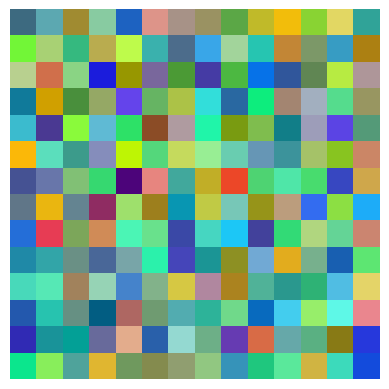

<Figure size 640x480 with 0 Axes>

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import sys, os

# 1. 패치 분할 : 목적 - 이미지를 16x16패치로 나누고, 각 패치를 768차원 벡터로 변환
def patch_embedding():
    '''이미지를 패치로 분할하는 과정(patch embedding)'''
    # 설정
    image_size = 224   # (224 x 224)
    patch_size = 16    # (16 x 16)
    channels = 3
    embedding_dim = 768  # (16x16x3) ViT-Base 모델은 768차원 벡터로 표현되도록 설계된 모델임

    # 패치수 계산
    num_patches = (image_size//patch_size) **2
    print(f'이미지 크기 : {image_size} x {image_size}')
    print(f'패치크기 : {patch_size} x {patch_size}')
    print(f'채널 수 : {channels}')
    print(f'패치 수 : {num_patches} = {image_size//patch_size} x {image_size//patch_size}')

    # 더미 이미지 생성
    dummy_imgae = torch.randn(1,channels, image_size, image_size)
    print (f'더미 이미지 생성')
    print(f'입력 이미지 shape : {dummy_imgae.shape}')   # 예상 [1, 3, 224, 224]

    # 패치 분할 : CNN의 Conv2d 사용
    # Conv2d stride = patch_size 겹치지 않는 패치 추출 
        # ----> 자연어처럼 처리하기 위해서.. stride 겹치지 않게 함.. 채널의 크기만큼 스트라이드를 이동해서 겹치지 않도록 추출함
    patch_embed = nn.Conv2d(
        in_channels=channels, 
        out_channels=embedding_dim, 
        kernel_size=patch_size, 
        stride=patch_size)

    # 패치 임베딩 적용
    patches = patch_embed(dummy_imgae)
    print(f"\n패치임베딩 후")
    print(f"Conv2d 출력 shape : {patches.shape}")   # 예상 [1, 768, 14(224/16), 14(224/16)]

    # Flatten : (B,D,H,W) == (Batch, Dim??, Hight??, Width??)  ---> 펼쳐주기 : (B, N, D) (1,196(14x14), 768)
    patches_flat = patches.flatten(2).transpose(1,2)  # ???????????????????/
    print(f"Flatten 후 shape : {patches_flat.shape}")  # [1,196,768]

    # 각 패치는 768차원 벡터
    print(f"\n패치 수 : {patches_flat.shape[1]}")
    print(f"각 패치의 임베딩 차원 수 : {patches_flat.shape[2]}")
    return patches_flat


# 2. 위치 임베딩의 역할: 목적 - Transformer는 순서 개념이 없음 --> 위치 정보를 벡터로 알려줘야함
def positional_embedding():
    '''위치 임베딩'''
    num_patches = 196 # (224/16) x (224/16)
    embedding_dim = 768
    print('\n=================================================\n')


    # 위치 임베딩 생성
        # ---> 이 텐서는 학습대상 Optimizer에 의해 업데이트
    position_embedding = nn.Parameter(torch.randn(1, num_patches+1, embedding_dim))  # +1은 CLS 토큰
    print (f"위치 임베딩 shape : {position_embedding.shape}")
    print(f"총 위치 수 : {num_patches+1} (패치 196 + cls토큰 1)")
    
    # 배치차원 제거 : 각 위치를 하나의 벡터로 다루기 위해 배치크기가 1인 형태는 분석시 불필요
    pos_emb = position_embedding.squeeze(0)   # 스퀴즈 빼기..

    # 코사인 유사도 계산을 위해서 정규화는 필수
    pos_emb_norm = pos_emb/pos_emb.norm(dim=1, keepdim=True) # 단위벡터로 나눔

    # 코사인 유사도 행렬
    similarity = torch.mm(pos_emb_norm, pos_emb_norm.t())  # 자기자신과 비교하는 행렬..
    print(f"유사도 행렬 shape : {similarity.shape}") # [197, 197]
    
    # 학습전이라서 랜덤이지만 학습후에는 인접 패치끼리 유사해짐..위치 임베딩 벡터들이 서로 비슷해질수 있다

    return position_embedding


# 3. CLS 토큰 : 이미지 전체를 대표하는 토큰 (최종분류는 CLS토큰만 사용)
def cls_token():
    embedding_dim = 768
    num_paches = 196
    batch_size = 2
    print('\n=================================================\n')

    # cls 토큰 생성
    cls_token = nn.Parameter(torch.rand(1,1,embedding_dim)) # 학습을 통해 이미지를 요약하는 벡터로 진화
    print(f"CLS 토큰 : {cls_token}")
    print(f"CLS 토큰 shape : {cls_token.shape}") # [1,1,768]

    # 배치크기에 맞게 CLS 토큰 확장
    cls_tokens = cls_token.expand(batch_size, -1, -1)  # 배치마다 동일한 cls 토큰이 필요, expand는 view만 확장
    print(f"배치 확장 후 cls : {cls_tokens}")
    print(f"배치 확장 후 cls shape : {cls_tokens.shape}")  # [2,1,768]

    # 패치 임베딩 생성
    patch_embeddings = torch.randn(batch_size, num_paches, embedding_dim)
    print(f"패치 임베딩 shape : {patch_embeddings.shape}")
    
    # CLS 토큰을 시퀀스 맨 앞에 추가
    embeddings=torch.cat([cls_tokens, patch_embeddings], dim=1)  # dim=1 토큰차원.. [cls | patch1 ... patch196 ]
    print(f"cls 와 패치 결합 후 임베딩 : {embeddings}")
    print(f"cls 와 패치 결합 후 shape : {embeddings.shape} ") # [2,197,768]

    # BERT에 CLS를 영감받아서 만든것..
     # CLS 문장 전체를 대표. 문장 맨앞에 있음
    
    return embeddings


# 4. self-attention : 패치들이 서로를 얼마나 참고하는지 계산
# Q(query) 내가 찾고 싶은 것
# K(key) 문서의 요약 키
# V(value) 문서의 실제 내용
# 1) Q와 K를 비교해서 중요도를 계산 Q*K ==> 관련성 점수 
# 2) 그 중요도로 v를 가중합
# 비교용(QK)과 정보 전달용(V)을 분리
def self_attention():
    '''self-attention 메커니즘
    Multi-Head Self-attention의 구성요소
    Q(query) K(key) V(value)'''
    embedding_dim = 768
    num_heads = 12
    head_dim = embedding_dim//num_heads  # 각 헤드가 담당하는 차원
    seq_len = 197  # 196패치 + 1 CLS (토큰수)
    batch_size =1  # 샘플 1개
    print('\n=================================================\n')


    # 더미데이터 생성
    x = torch.randn(batch_size, seq_len, embedding_dim) # (1,197,768)
    
    # QKV 선형 레이어
    qkv_proj = nn.Linear(embedding_dim, embedding_dim*3) # 하나의 Linear 연산으로 QKV 동시에 생성

    # QKV 계산
    qkv = qkv_proj(x)
    print(f"QKV shape : {qkv.shape}") # [1, 197, 2304(768x3(q,k,v))] 

    # Q K V 분리 .. 차원분리?????
    qkv = qkv.reshape(batch_size, seq_len, 3, num_heads, head_dim)  # [B, N(토큰수), 3(Q/K/V), heads, head_dim]
    print(f"reshape 이후 QKV : {qkv.shape}")
    qkv = qkv.permute(2,0,3,1,4) # [3, B, heads, N, head_dim] [3, 1, 12, 197, 64]) ??????????????????
    print(f"permute 이후 QKV : {qkv.shape}")
    q, k, v = qkv[0], qkv[1], qkv[2]
    print(f"Q shape : {q.shape}")   # 동일한 모양
    print(f"K shape : {k.shape}")   # 동일한 모양
    print(f"V shape : {v.shape}")   # 동일한 모양

    # Attention Score 계산
    scale = head_dim ** -0.5
    attn = (q @ k.transpose(-2, -1)) * scale
    print(f"\n[Attention Score]")
    print(f"  Attention shape: {attn.shape}")  # [1, 12, 197, 197]
    
    # Softmax
    attn = attn.softmax(dim=-1)
    print(f"  Softmax 후 합계 (각 행): {attn[0, 0, 0].sum().item():.4f}")  # 1.0
    
    # Value와 곱하기
    out = attn @ v
    print(f"\n[Attention 적용]")
    print(f"  출력 shape: {out.shape}")  # [1, 12, 197, 64]
    
    # 헤드 결합
    out = out.transpose(1, 2).reshape(batch_size, seq_len, embedding_dim)
    print(f"  헤드 결합 후: {out.shape}")  # [1, 197, 768]
    
    return attn



def mlp():
    '''mlp 블럭'''
    embedding_dim = 768
    mlp_dim = embedding_dim*4 #일반적으로 4배 확장
    print(f"입력/출력 차원: {embedding_dim}")
    print(f"히든 차원 : {mlp_dim}")
    
    # MLP 블럭 정의
    mlp = nn.Sequential(
        nn.Linear(embedding_dim, mlp_dim),
        nn.GELU(), # 단순 선형을 비선형으로 변형
        nn.Linear(mlp_dim, embedding_dim)
    )

    # 파라미터 수 계산
    total_params = sum(p.numel() for p in mlp.parameters())
    print(f"  MLP 파라미터 수: {total_params:,}")
    
    # 더미 입력
    x = torch.randn(1, 197, embedding_dim)
    print(f"\n[입력/출력]")
    print(f"  입력 shape: {x.shape}")
    
    # MLP 적용
    out = mlp(x)
    print(f"  출력 shape: {out.shape}")
    
    print(f"\n[GELU 활성화 함수]")
    print(f"  GELU(x) = x * Phi(x)")
    print(f"  ReLU보다 부드럽고, 음수 입력에도 작은 값 출력")
    
    return out



# Transformer Encoder block 구조
def transformer_block():
    '''transformer Encoder 블럭'''
    class TransformerBlock(nn.Module):
        """간단한 Transformer Block 구현"""
        def __init__(self, dim=768, num_heads=12, mlp_ratio=4.0):
            super().__init__()
            self.norm1 = nn.LayerNorm(dim)
            self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
            self.norm2 = nn.LayerNorm(dim)
            self.mlp = nn.Sequential(
                nn.Linear(dim, int(dim * mlp_ratio)),
                nn.GELU(),
                nn.Linear(int(dim * mlp_ratio), dim),
            )
        
        def forward(self, x):
            # Pre-norm 구조
            # Attention with residual
            x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
            # MLP with residual
            x = x + self.mlp(self.norm2(x))
            return x
    
    # 블록 생성
    block = TransformerBlock()
    
    # 파라미터 수
    total_params = sum(p.numel() for p in block.parameters())
    print(f"\n[Transformer Block 구성]")
    print(f"1. Layer Normalization")
    print(f"2. Multi-Head Self-Attention")
    print(f"3. Residual Connection")
    print(f"4. Layer Normalization")
    print(f"5. MLP (Feed-Forward)")
    print(f"6. Residual Connection")
    print(f"\n블록당 파라미터 수: {total_params:,}")
    
    # 더미 입력
    x = torch.randn(1, 197, 768)
    print(f"\n[입력/출력]")
    print(f"입력 shape: {x.shape}")
    
    out = block(x)
    print(f"출력 shape: {out.shape}")
    
    # ViT-Base는 12개 블록
    print(f"\n[ViT-Base 전체 파라미터]")
    print(f"12개 블록 파라미터: {total_params * 12:,}")
    
    return block



# self attention이 어디를 주목하는지 시각화
def main():
    # 1. 패치 임베딩 
    patches = patch_embedding()
    # 2 . 위치임베딩
    pos_embed = positional_embedding()
    # 3. CLS 토큰
    embeddings = cls_token()
    # 4. self attention 
    attention = self_attention()
    # 5. MLP
    mlp_output = mlp()
    # 6. transformer block
    block = transformer_block()

def _visualization_cls_attention(attn, image_size=224, patch_size=16):
    '''cls토큰이 각 패치를 얼마나 주목하는지 시각화
    attn : [1,heads, 197, 197]'''

    # cls --> patch attention만 추출
    cls_attn = attn[0, :, 0, 1: ] # [heads, 196] ??????
    # head 평균
    cls_attn_mean = cls_attn.mean(dim=0) # [196]
    # 14 x 14 reshape
    grid_size = image_size // patch_size
    attn_map = cls_attn_mean.reshape(grid_size, grid_size)
    # 정규화
    attn_map = attn_map/ attn_map.max()
    return attn_map.detach().cpu().numpy()

# 더미이미지 + Attention 시각화
def demo_cls_attention_visualization():
    # 1. 더미 이미지
    image = np.random.rand(224,224,3)
    # 2. self attention 계산
    attn = self_attention()
    # 3. attention map 생성
    attn_map = _visualization_cls_attention(attn)
    # 4. 시각화
    plt.imshow(image)
    plt.imshow(attn_map, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show() 
    # plt.savefig('13_3_vit_visualization.png') # 파일로 저장



if __name__ == '__main__' :
    # main()
    demo_cls_attention_visualization()

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 이미지셀 관련 커널 충돌로 인해 추가함

#### 고양이 사진 넣어서 self attention 확인



QKV shape : torch.Size([1, 197, 2304])
reshape 이후 QKV : torch.Size([1, 197, 3, 12, 64])
permute 이후 QKV : torch.Size([3, 1, 12, 197, 64])
Q shape : torch.Size([1, 12, 197, 64])
K shape : torch.Size([1, 12, 197, 64])
V shape : torch.Size([1, 12, 197, 64])

[Attention Score]
  Attention shape: torch.Size([1, 12, 197, 197])
  Softmax 후 합계 (각 행): 1.0000

[Attention 적용]
  출력 shape: torch.Size([1, 12, 197, 64])
  헤드 결합 후: torch.Size([1, 197, 768])


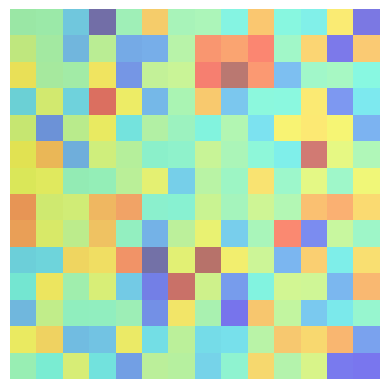

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import sys, os

# 1. 패치 분할
def patch_embedding():
    '''이미지를 패치로 분할하는 과정(patch embedding)'''
    # 설정
    image_size = 224   # (224 x 224)
    patch_size = 16    # (16 x 16)
    channels = 3
    embedding_dim = 768

    # 패치수 계산
    num_patches = (image_size//patch_size) **2
    print(f'이미지 크기 : {image_size} x {image_size}')
    print(f'패치크기 : {patch_size} x {patch_size}')
    print(f'채널 수 : {channels}')
    print(f'패치 수 : {num_patches} = {image_size//patch_size} x {image_size//patch_size}')

    # 더미 이미지 생성
    dummy_imgae = torch.randn(1,channels, image_size, image_size)
    print (f'더미 이미지 생성')
    print(f'입력 이미지 shape : {dummy_imgae.shape}')   # 예상 [1, 3, 224, 224]

    # 패치 분할 : CNN의 Conv2d 사용
    # Conv2d stride = patch_size 겹치지 않는 패치 추출 
        # ----> 자연어처럼 처리하기 위해서.. stride 겹치지 않게 함.. 채널의 크기만큼 스트라이드를 이동해서 겹치지 않도록 추출함
    patch_embed = nn.Conv2d(in_channels=channels, out_channels=embedding_dim, kernel_size=patch_size, stride=patch_size)

    # 패치 임베딩 적용
    patches = patch_embed(dummy_imgae)
    print(f"\n패치임베딩 후")
    print(f"Conv2d 출력 shape : {patches.shape}")   # 예상 [1, 768, 14(224/16), 14(224/16)]

    # Flatten : (B,D,H,W) == (Batch, Dim??, Hight??, Width??)  ---> 펼쳐주기 : (B, N, D) (1,196(14x14), 768)
    patches_flat = patches.flatten(2).transpose(1,2)  # ???????????????????/
    print(f"Flatten 후 shape : {patches_flat.shape}")  # [1,196,768]

    # 각 패치는 768차원 벡터
    print(f"\n패치 수 : {patches_flat.shape[1]}")
    print(f"각 패치의 임베딩 차원 수 : {patches_flat.shape[2]}")
    return patches_flat


# 위치 임베딩의 역할
def positional_embedding():
    '''위치 임베딩'''
    num_patches = 196 # (224/16) x (224/16)
    embedding_dim = 768
    print('\n=================================================\n')


    # 위치 임베딩 생성
        # ---> 이 텐서는 학습대상 Optimizer에 의해 업데이트
    position_embedding = nn.Parameter(torch.randn(1, num_patches+1, embedding_dim))  # +1은 CLS 토큰
    print (f"위치 임베딩 shape : {position_embedding.shape}")
    print(f"총 위치 수 : {num_patches+1} (패치 196 + cls토큰 1)")
    
    # 배치차원 제거 : 각 위치를 하나의 벡터로 다루기 위해 배치크기가 1인 형태는 분석시 불필요
    pos_emb = position_embedding.squeeze(0)   # 스퀴즈 빼기..

    # 코사인 유사도 계산을 위해서 정규화는 필수
    pos_emb_norm = pos_emb/pos_emb.norm(dim=1, keepdim=True) # 단위벡터로 나눔

    # 코사인 유사도 행렬
    similarity = torch.mm(pos_emb_norm, pos_emb_norm.t())  # 자기자신과 비교하는 행렬..
    print(f"유사도 행렬 shape : {similarity.shape}") # [197, 197]
    
    # 학습전이라서 랜덤이지만 학습후에는 인접 패치끼리 유사해짐 ?? 무엇이..?

    return position_embedding


# 3. CLS 토큰
def cls_token():
    embedding_dim = 768
    num_paches = 196
    batch_size = 2
    print('\n=================================================\n')

    # cls 토큰 생성
    cls_token = nn.Parameter(torch.rand(1,1,embedding_dim)) # 학습을 통해 이미지를 요약하는 벡터로 진화
    print(f"CLS 토큰 : {cls_token}")
    print(f"CLS 토큰 shape : {cls_token.shape}") # [1,1,768]

    # 배치크기에 맞게 CLS 토큰 확장
    cls_tokens = cls_token.expand(batch_size, -1, -1)  # 배치마다 동일한 cls 토큰이 필요, expand는 view만 확장
    print(f"배치 확장 후 cls : {cls_tokens}")
    print(f"배치 확장 후 cls shape : {cls_tokens.shape}")  # [2,1,768]

    # 패치 임베딩 생성
    patch_embeddings = torch.randn(batch_size, num_paches, embedding_dim)
    print(f"패치 임베딩 shape : {patch_embeddings.shape}")
    
    # CLS 토큰을 시퀀스 맨 앞에 추가
    embeddings=torch.cat([cls_tokens, patch_embeddings], dim=1)  # dim=1 토큰차원.. [cls | patch1 ... patch196 ]
    print(f"cls 와 패치 결합 후 임베딩 : {embeddings}")
    print(f"cls 와 패치 결합 후 shape : {embeddings.shape} ") # [2,197,768]

    # BERT에 CLS를 영감받아서 만든것..
     # CLS 문장 전체를 대표. 문장 맨앞에 있음
    
    return embeddings


# 4. self-attention
def self_attention():
    '''self-attention 메커니즘
    Multi-Head Self-attention의 구성요소
    Q(query) K(key) V(value)'''
    embedding_dim = 768
    num_heads = 12
    head_dim = embedding_dim//num_heads  # 각 헤드가 담당하는 차원
    seq_len = 197  # 196패치 + 1 CLS
    batch_size =1  # 샘플 1개
    print('\n=================================================\n')


    # 더미데이터 생성
    x = torch.randn(batch_size, seq_len, embedding_dim) # (1,197,768)
    
    # QKV 선형 레이어
    qkv_proj = nn.Linear(embedding_dim, embedding_dim*3) # 하나의 Linear 연산으로 QKV 동시에 생성

    # QKV 계산
    qkv = qkv_proj(x)
    print(f"QKV shape : {qkv.shape}") # [1, 197, 2304(768x3)] 

    # Q K V 분리 .. 차원분리?????
    qkv = qkv.reshape(batch_size, seq_len, 3, num_heads, head_dim)  # [B, N, 3, heads, head_dim]
    print(f"reshape 이후 QKV : {qkv.shape}")
    qkv = qkv.permute(2,0,3,1,4) # [3, B, heads, N, head_dim] [3, 1, 12, 197, 64]) ??????????????????
    print(f"permute 이후 QKV : {qkv.shape}")
    q, k, v = qkv[0], qkv[1], qkv[2]
    print(f"Q shape : {q.shape}")   # 동일한 모양
    print(f"K shape : {k.shape}")   # 동일한 모양
    print(f"V shape : {v.shape}")   # 동일한 모양

    # Attention Score 계산
    scale = head_dim ** -0.5
    attn = (q @ k.transpose(-2, -1)) * scale
    print(f"\n[Attention Score]")
    print(f"  Attention shape: {attn.shape}")  # [1, 12, 197, 197]
    
    # Softmax
    attn = attn.softmax(dim=-1)
    print(f"  Softmax 후 합계 (각 행): {attn[0, 0, 0].sum().item():.4f}")  # 1.0
    
    # Value와 곱하기
    out = attn @ v
    print(f"\n[Attention 적용]")
    print(f"  출력 shape: {out.shape}")  # [1, 12, 197, 64]
    
    # 헤드 결합
    out = out.transpose(1, 2).reshape(batch_size, seq_len, embedding_dim)
    print(f"  헤드 결합 후: {out.shape}")  # [1, 197, 768]
    
    return attn



def mlp():
    '''mlp 블럭'''
    embedding_dim = 768
    mlp_dim = embedding_dim*4 #일반적으로 4배 확장
    print(f"입력/출력 차원: {embedding_dim}")
    print(f"히든 차원 : {mlp_dim}")
    
    # MLP 블럭 정의
    mlp = nn.Sequential(
        nn.Linear(embedding_dim, mlp_dim),
        nn.GELU(), # 단순 선형을 비선형으로 변형
        nn.Linear(mlp_dim, embedding_dim)
    )

    # 파라미터 수 계산
    total_params = sum(p.numel() for p in mlp.parameters())
    print(f"  MLP 파라미터 수: {total_params:,}")
    
    # 더미 입력
    x = torch.randn(1, 197, embedding_dim)
    print(f"\n[입력/출력]")
    print(f"  입력 shape: {x.shape}")
    
    # MLP 적용
    out = mlp(x)
    print(f"  출력 shape: {out.shape}")
    
    print(f"\n[GELU 활성화 함수]")
    print(f"  GELU(x) = x * Phi(x)")
    print(f"  ReLU보다 부드럽고, 음수 입력에도 작은 값 출력")
    
    return out



# Transformer Encoder block 구조
def transformer_block():
    '''transformer Encoder 블럭'''
    class TransformerBlock(nn.Module):
        """간단한 Transformer Block 구현"""
        def __init__(self, dim=768, num_heads=12, mlp_ratio=4.0):
            super().__init__()
            self.norm1 = nn.LayerNorm(dim)
            self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
            self.norm2 = nn.LayerNorm(dim)
            self.mlp = nn.Sequential(
                nn.Linear(dim, int(dim * mlp_ratio)),
                nn.GELU(),
                nn.Linear(int(dim * mlp_ratio), dim),
            )
        
        def forward(self, x):
            # Pre-norm 구조
            # Attention with residual
            x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
            # MLP with residual
            x = x + self.mlp(self.norm2(x))
            return x
    
    # 블록 생성
    block = TransformerBlock()
    
    # 파라미터 수
    total_params = sum(p.numel() for p in block.parameters())
    print(f"\n[Transformer Block 구성]")
    print(f"1. Layer Normalization")
    print(f"2. Multi-Head Self-Attention")
    print(f"3. Residual Connection")
    print(f"4. Layer Normalization")
    print(f"5. MLP (Feed-Forward)")
    print(f"6. Residual Connection")
    print(f"\n블록당 파라미터 수: {total_params:,}")
    
    # 더미 입력
    x = torch.randn(1, 197, 768)
    print(f"\n[입력/출력]")
    print(f"입력 shape: {x.shape}")
    
    out = block(x)
    print(f"출력 shape: {out.shape}")
    
    # ViT-Base는 12개 블록
    print(f"\n[ViT-Base 전체 파라미터]")
    print(f"12개 블록 파라미터: {total_params * 12:,}")
    
    return block



# self attention이 어디를 주목하는지 시각화
def main():
    # 1. 패치 임베딩 
    patches = patch_embedding()
    # 2 . 위치임베딩
    pos_embed = positional_embedding()
    # 3. CLS 토큰
    embeddings = cls_token()
    # 4. self attention 
    attention = self_attention()
    # 5. MLP
    mlp_output = mlp()
    # 6. transformer block
    block = transformer_block()

def _visualization_cls_attention(attn, image_size=224, patch_size=16):
    '''cls토큰이 각 패치를 얼마나 주목하는지 시각화
    attn : [1,heads, 197, 197]'''

    # cls --> patch attention만 추출
    cls_attn = attn[0, :, 0, 1: ] # [heads, 196] ??????
    # head 평균
    cls_attn_mean = cls_attn.mean(dim=0) # [196]
    # 14 x 14 reshape
    grid_size = image_size // patch_size
    attn_map = cls_attn_mean.reshape(grid_size, grid_size)
    # 정규화
    attn_map = attn_map/ attn_map.max()
    return attn_map.detach().cpu().numpy()

# 더미이미지 + Attention 시각화
import requests
from PIL import Image
from io import BytesIO
def demo_cls_attention_visualization(is_dummy:bool=True, url:str = None, image_size:str = 224) :
    # 1. 더미 이미지
    if is_dummy : 
        image = np.random.rand(224,224,3)
    elif url.startswith("http"):
        response = requests.get(url)
        image = Image.open(BytesIO(response.content)).convert('RGB')
        image = image.resize((image_size, image_size))
        image = np.array(image) / 255.0  # 정규화
    else : # 로컬이미지 로드
        image = Image.open(url).convert('RGB')
        image = image.resize((image_size, image_size))
        image = np.array(image) / 255.0  # 정규화    


    # 2. self attention 계산
    attn = self_attention()
    # 3. attention map 생성
    attn_map = _visualization_cls_attention(attn)
    # 4. 시각화
    plt.imshow(image)
    plt.imshow(attn_map, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show() 
    # plt.savefig('13_3_vit_visualization.png') # 파일로 저장



if __name__ == '__main__' :
    # main()
    url = 'C:/00AI/LLM/20openai/14vit_image/Cat03.jpg'
    demo_cls_attention_visualization(False, url=url)
